In [42]:
# Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (541909, 8)


In [43]:
# Initial Data Inspection

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing Values:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Duplicate Records: 5268

Descriptive Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [44]:
# Check Cancellations and Invalid Records

print("Cancelled Invoices:")
display(df['InvoiceNo'].astype(str).str.startswith('C').value_counts())

print("\nNegative Quantity Records:")
display(df[df['Quantity'] < 0].head())

print("\nNegative Unit Price Records:")
display(df[df['UnitPrice'] < 0].head())

Cancelled Invoices:


InvoiceNo
False    532621
True       9288
Name: count, dtype: int64


Negative Quantity Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom



Negative Unit Price Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [45]:
# Data Cleaning

# Remove duplicate records
df = df.drop_duplicates()

# Remove records with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled and returned transactions
df = df[df['Quantity'] > 0]

# Remove invalid unit prices
df = df[df['UnitPrice'] > 0]

print("Data cleaning completed!")
print("Cleaned dataset shape:", df.shape)

Data cleaning completed!
Cleaned dataset shape: (392692, 8)


In [46]:
# Verify Cleaned Data

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nNegative Quantities:", (df['Quantity'] < 0).sum())

print("Invalid Unit Prices:", (df['UnitPrice'] <= 0).sum())

Missing Values:


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


Duplicate Records: 0

Negative Quantities: 0
Invalid Unit Prices: 0


In [47]:
# Feature Engineering

# Calculate total amount spent on each transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check the new features
display(df[['CustomerID', 'Quantity', 'UnitPrice', 'TotalAmount', 'InvoiceDate']].head())

print("Feature engineering completed!")

,CustomerID,Quantity,UnitPrice,TotalAmount,InvoiceDate
0,17850.0,6,2.55,15.30,2010-12-01 08:26:00
1,17850.0,6,3.39,20.34,2010-12-01 08:26:00
2,17850.0,8,2.75,22.00,2010-12-01 08:26:00
3,17850.0,6,3.39,20.34,2010-12-01 08:26:00
4,17850.0,6,3.39,20.34,2010-12-01 08:26:00


Feature engineering completed!


In [48]:
# Create Customer-Level Features

# Set analysis date as one day after the last transaction
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate transaction data at customer level
customer_data = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

# Calculate Average Order Value
customer_data['AverageOrderValue'] = (
    customer_data['Monetary'] / customer_data['Frequency']
)

# Display customer-level data
display(customer_data.head())

print("Number of unique customers:", customer_data['CustomerID'].nunique())

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
0,12346.0,326,1,77183.60,77183.600000
1,12347.0,2,7,4310.00,615.714286
2,12348.0,75,4,1797.24,449.310000
3,12349.0,19,1,1757.55,1757.550000
4,12350.0,310,1,334.40,334.400000


Number of unique customers: 4338


In [49]:
# Customer Data Summary

print("Customer-Level Data Shape:", customer_data.shape)

print("\nSummary Statistics:")
display(customer_data[['Recency', 'Frequency', 'Monetary', 'AverageOrderValue']].describe())

Customer-Level Data Shape: (4338, 5)

Summary Statistics:


,Recency,Frequency,Monetary,AverageOrderValue
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,417.645735
std,100.014169,7.697998,8985.230220,1796.511343
min,1.000000,1.000000,3.750000,3.450000
25%,18.000000,1.000000,306.482500,177.867083
50%,51.000000,2.000000,668.570000,291.940000
75%,142.000000,5.000000,1660.597500,428.280625
max,374.000000,209.000000,280206.020000,84236.250000


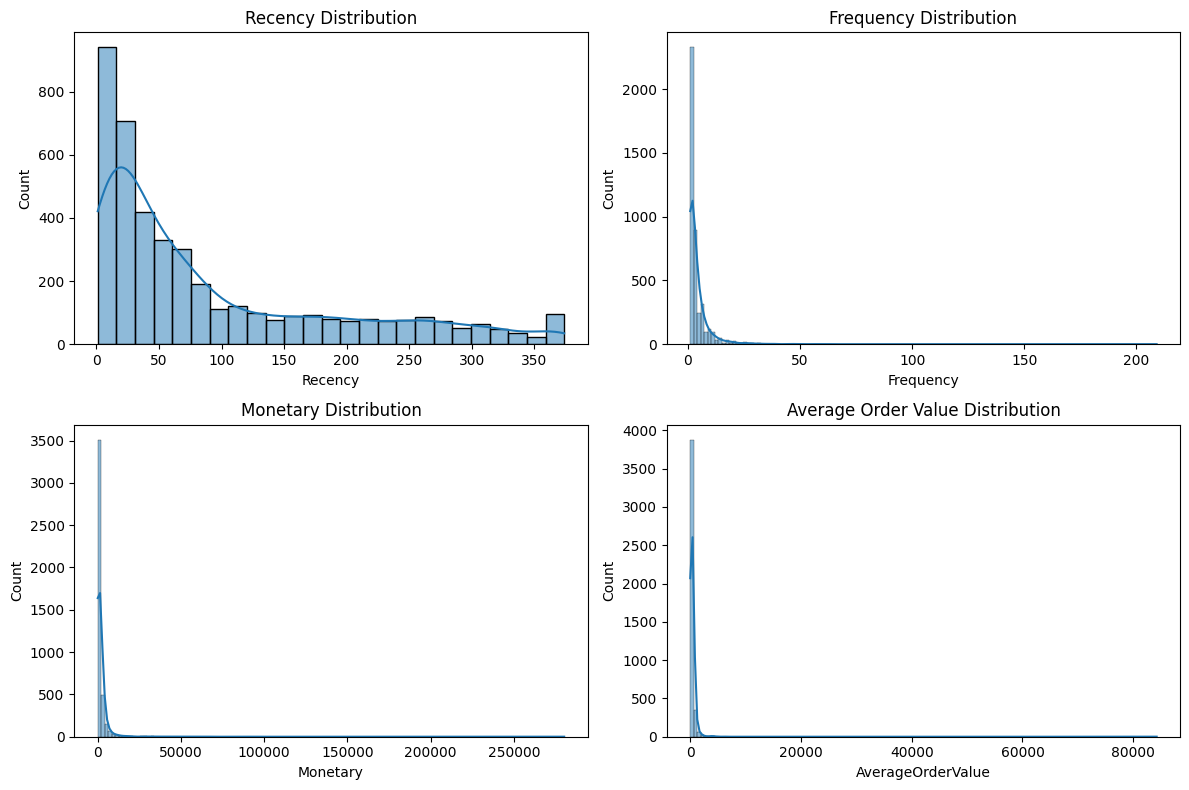

In [50]:
# Customer Feature Distributions

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(customer_data['Recency'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Recency Distribution')

sns.histplot(customer_data['Frequency'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Frequency Distribution')

sns.histplot(customer_data['Monetary'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Monetary Distribution')

sns.histplot(customer_data['AverageOrderValue'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Average Order Value Distribution')

plt.tight_layout()
plt.show()

In [51]:
# Prepare Features for Clustering

features = ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue']

# Apply log transformation
clustering_data = customer_data[features].copy()

clustering_data = np.log1p(clustering_data)

display(clustering_data.head())

print("Features prepared for clustering.")

,Recency,Frequency,Monetary,AverageOrderValue
0,5.789960,0.693147,11.253955,11.253955
1,1.098612,2.079442,8.368925,6.424406
2,4.330733,1.609438,7.494564,6.109936
3,2.995732,0.693147,7.472245,7.472245
4,5.739793,0.693147,5.815324,5.815324


Features prepared for clustering.


In [52]:
# Standardize Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(clustering_data)

scaled_features = pd.DataFrame(
    scaled_features,
    columns=features
)

display(scaled_features.head())

print("Features standardized successfully!")

,Recency,Frequency,Monetary,AverageOrderValue
0,1.461993,-0.955214,3.707716,7.522807
1,-2.038734,1.074425,1.414903,1.044160
2,0.373104,0.386304,0.720024,0.622312
3,-0.623086,-0.955214,0.702287,2.449794
4,1.424558,-0.955214,-0.614514,0.227101


Features standardized successfully!


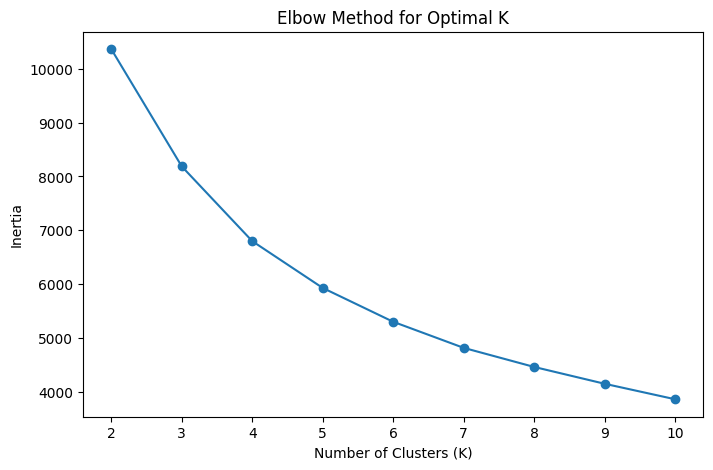

In [53]:
# Find Optimal Number of Clusters Using Elbow Method

from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.show()

In [54]:
# Validate Number of Clusters Using Silhouette Score

from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(scaled_features, labels)
    silhouette_scores[k] = score

print("Silhouette Scores:")
for k, score in silhouette_scores.items():
    print(f"K = {k}: {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)

print(f"\nBest K based on Silhouette Score: {best_k}")

Silhouette Scores:
K = 2: 0.3623
K = 3: 0.2790
K = 4: 0.2740
K = 5: 0.2675
K = 6: 0.2591

Best K based on Silhouette Score: 2


In [55]:
# Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

print("K-Means clustering completed!")
print("Number of clusters:", best_k)

K-Means clustering completed!
Number of clusters: 2


Number of Customers in Each Cluster:


Cluster
0    2636
1    1702
Name: count, dtype: int64

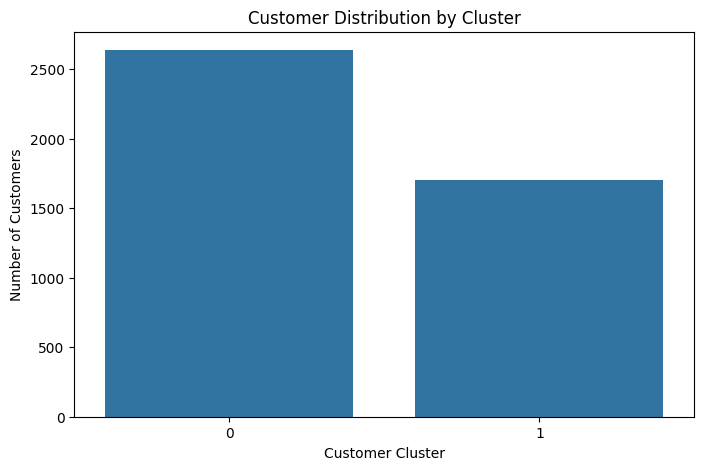

In [56]:
# Check Customer Distribution Across Clusters

cluster_counts = customer_data['Cluster'].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
display(cluster_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')
plt.show()

In [57]:
# Analyze Cluster Characteristics

cluster_profile = customer_data.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue']
].mean().round(2)

display(cluster_profile)

,Recency,Frequency,Monetary,AverageOrderValue
Cluster,,,,
0,133.23,1.72,441.77,284.81
1,29.51,8.23,4537.43,623.37


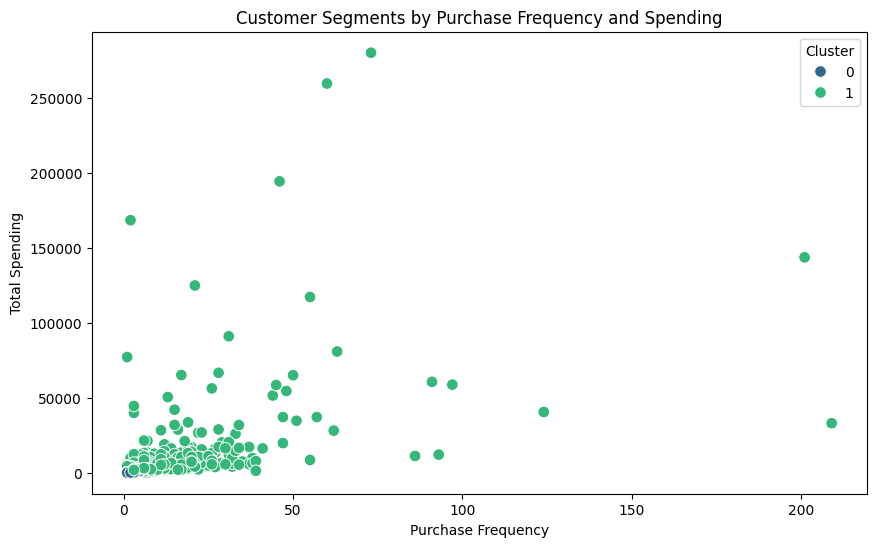

In [58]:
# Visualize Customer Segments

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.title('Customer Segments by Purchase Frequency and Spending')
plt.legend(title='Cluster')
plt.show()

In [59]:
# Assign Customer Segment Names

segment_names = {
    0: 'At-Risk / Low-Value Customers',
    1: 'High-Value Loyal Customers'
}

customer_data['Segment'] = customer_data['Cluster'].map(segment_names)

display(customer_data.head())

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,Cluster,Segment
0,12346.0,326,1,77183.60,77183.600000,1,High-Value Loyal Customers
1,12347.0,2,7,4310.00,615.714286,1,High-Value Loyal Customers
2,12348.0,75,4,1797.24,449.310000,1,High-Value Loyal Customers
3,12349.0,19,1,1757.55,1757.550000,1,High-Value Loyal Customers
4,12350.0,310,1,334.40,334.400000,0,At-Risk / Low-Value Customers


In [60]:
# Analyze Customer Segments

segment_summary = customer_data.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    AvgOrderValue=('AverageOrderValue', 'mean')
).round(2)

display(segment_summary)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgOrderValue
Segment,,,,,
At-Risk / Low-Value Customers,2636,133.23,1.72,441.77,284.81
High-Value Loyal Customers,1702,29.51,8.23,4537.43,623.37


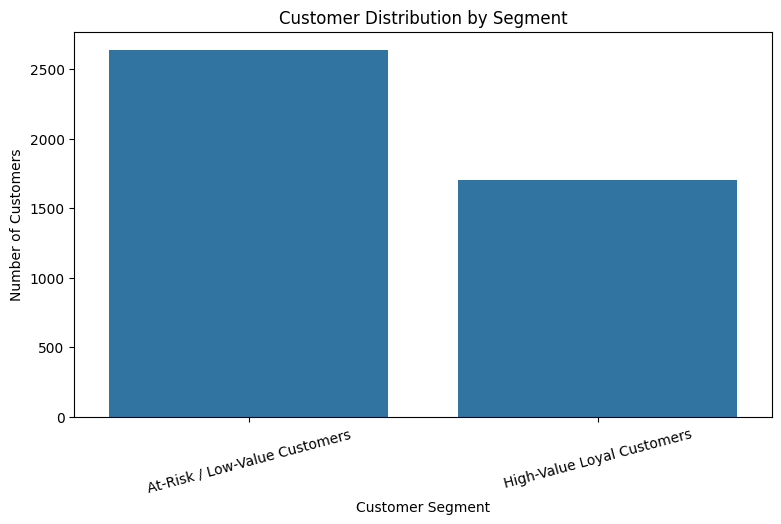

In [61]:
# Visualize Customer Segment Distribution

segment_counts = customer_data['Segment'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Segment')
plt.xticks(rotation=15)
plt.show()

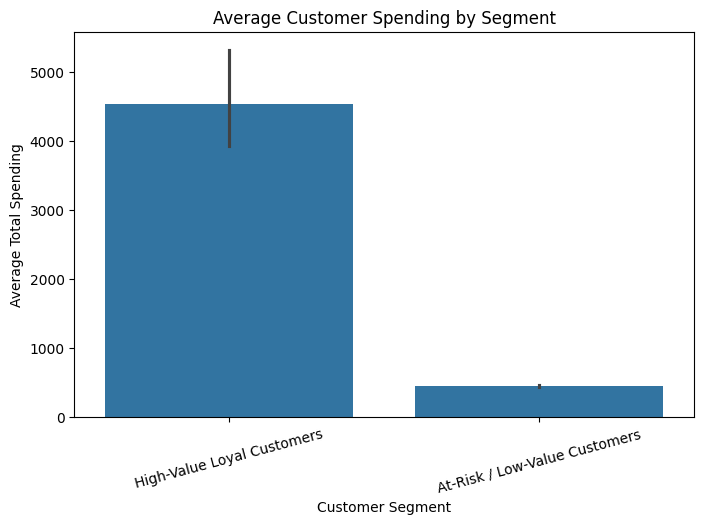

In [62]:
# Compare Average Spending Across Segments

plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_data,
    x='Segment',
    y='Monetary'
)

plt.xlabel('Customer Segment')
plt.ylabel('Average Total Spending')
plt.title('Average Customer Spending by Segment')
plt.xticks(rotation=15)
plt.show()

In [63]:
# Analyze Country Distribution by Segment

customer_country = df[['CustomerID', 'Country']].drop_duplicates()

customer_data_country = customer_data.merge(
    customer_country,
    on='CustomerID',
    how='left'
)

country_segment = pd.crosstab(
    customer_data_country['Country'],
    customer_data_country['Segment']
)

display(country_segment.sort_values(
    by=country_segment.columns.tolist(),
    ascending=False
).head(15))

Segment,At-Risk / Low-Value Customers,High-Value Loyal Customers
Country,,
United Kingdom,2416,1504
Germany,46,48
France,43,44
Spain,16,14
Portugal,12,7
Switzerland,11,10
Belgium,10,15
Italy,8,6
Finland,7,5


In [64]:
# Identify Top Products by Customer Segment

product_segment = df.merge(
    customer_data[['CustomerID', 'Segment']],
    on='CustomerID',
    how='inner'
)

top_products_segment = (
    product_segment.groupby(['Segment', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Segment', 'Quantity'], ascending=[True, False])
)

display(
    top_products_segment
    .groupby('Segment')
    .head(10)
)

,Segment,Description,Quantity
3483,At-Risk / Low-Value Customers,WORLD WAR 2 GLIDERS ASSTD DESIGNS,8260
489,At-Risk / Low-Value Customers,BROCADE RING PURSE,6084
210,At-Risk / Low-Value Customers,ASSORTED COLOURS SILK FAN,5996
1055,At-Risk / Low-Value Customers,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,5666
202,At-Risk / Low-Value Customers,ASSORTED COLOUR BIRD ORNAMENT,5108
3402,At-Risk / Low-Value Customers,WHITE HANGING HEART T-LIGHT HOLDER,4318
2972,At-Risk / Low-Value Customers,SMALL CHINESE STYLE SCISSOR,3773
2089,At-Risk / Low-Value Customers,PACK OF 72 RETROSPOT CAKE CASES,3615
2385,At-Risk / Low-Value Customers,POPART WOODEN PENCILS ASST,3600
123,At-Risk / Low-Value Customers,AGED GLASS SILVER T-LIGHT HOLDER,3598


In [65]:
# Identify Top 10 Products Overall

top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

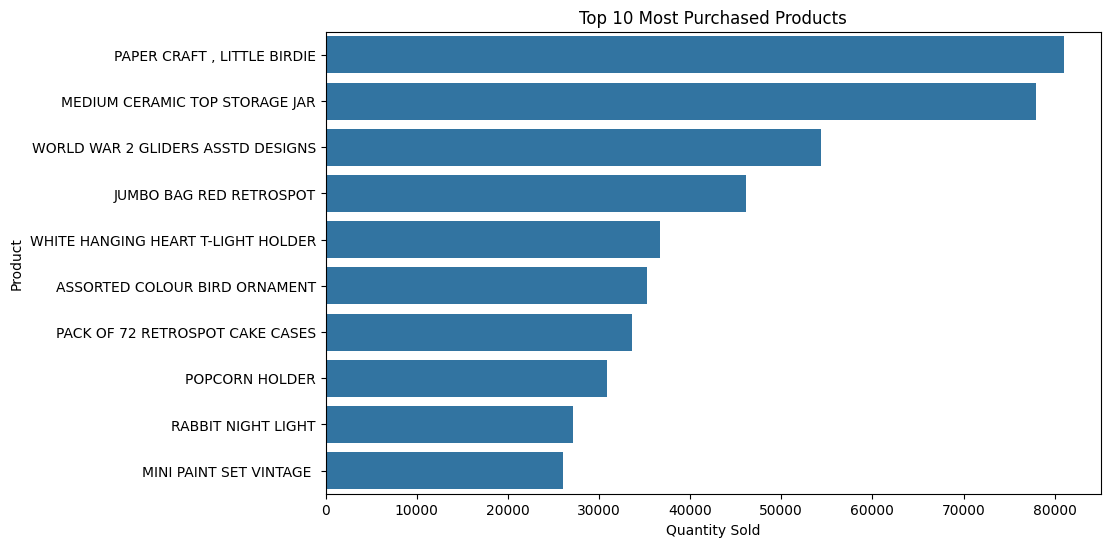

In [66]:
# Visualize Top 10 Products

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.title('Top 10 Most Purchased Products')
plt.show()

,AverageRecency,AverageFrequency
Segment,,
At-Risk / Low-Value Customers,133.23,1.72
High-Value Loyal Customers,29.51,8.23


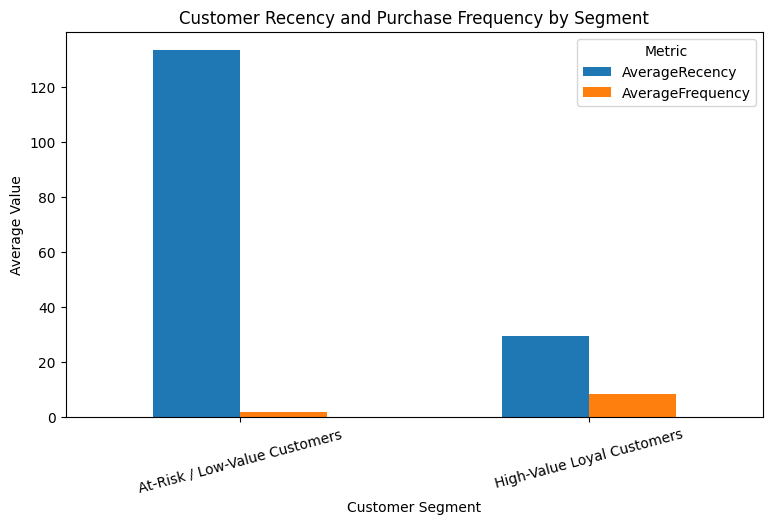

In [67]:
# Compare Recency and Purchase Frequency Across Segments

segment_behavior = customer_data.groupby('Segment').agg(
    AverageRecency=('Recency', 'mean'),
    AverageFrequency=('Frequency', 'mean')
).round(2)

display(segment_behavior)

segment_behavior.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.xlabel('Customer Segment')
plt.ylabel('Average Value')
plt.title('Customer Recency and Purchase Frequency by Segment')
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.show()

,Total Revenue,Revenue Contribution (%)
Segment,,
High-Value Loyal Customers,7722708.46,86.9
At-Risk / Low-Value Customers,1164500.43,13.1


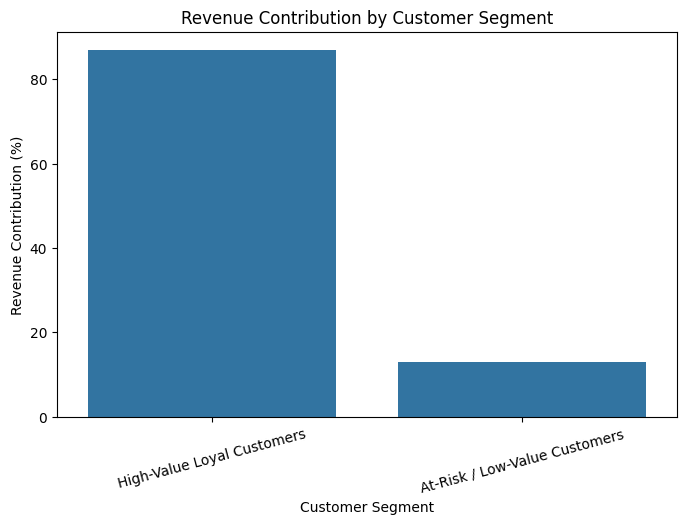

In [68]:
# Calculate Revenue Contribution by Customer Segment

segment_revenue = (
    customer_data.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

revenue_percentage = (
    segment_revenue / segment_revenue.sum() * 100
).round(2)

segment_revenue_summary = pd.DataFrame({
    'Total Revenue': segment_revenue.round(2),
    'Revenue Contribution (%)': revenue_percentage
})

display(segment_revenue_summary)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_revenue_summary.index,
    y=segment_revenue_summary['Revenue Contribution (%)']
)

plt.xlabel('Customer Segment')
plt.ylabel('Revenue Contribution (%)')
plt.title('Revenue Contribution by Customer Segment')
plt.xticks(rotation=15)
plt.show()

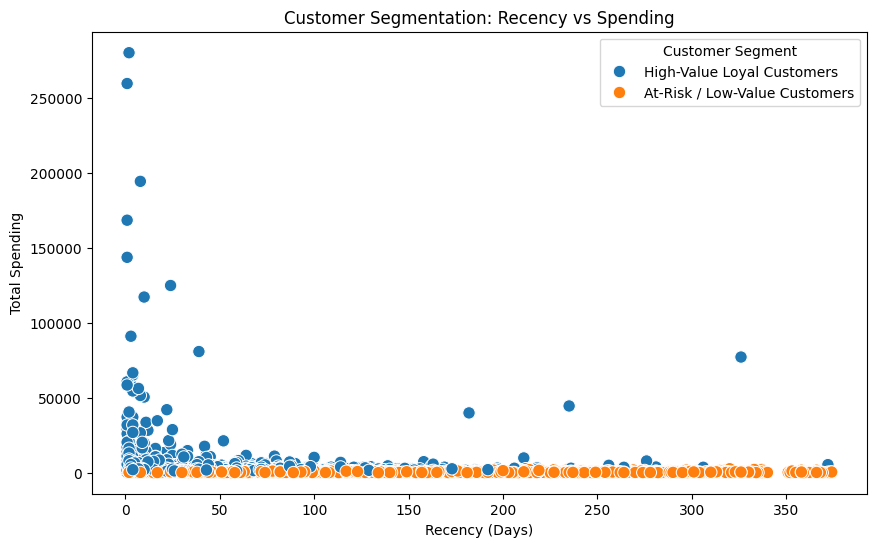

In [69]:
# Final Customer Segment Visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=80
)

plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')
plt.title('Customer Segmentation: Recency vs Spending')
plt.legend(title='Customer Segment')
plt.show()

In [70]:
# Final Segment Analysis

final_segment_analysis = customer_data.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Average_Recency=('Recency', 'mean'),
    Average_Frequency=('Frequency', 'mean'),
    Average_Spending=('Monetary', 'mean'),
    Average_Order_Value=('AverageOrderValue', 'mean')
).round(2)

final_segment_analysis['Customer_Percentage'] = (
    final_segment_analysis['Customers'] /
    final_segment_analysis['Customers'].sum() * 100
).round(2)

display(final_segment_analysis)

,Customers,Average_Recency,Average_Frequency,Average_Spending,Average_Order_Value,Customer_Percentage
Segment,,,,,,
At-Risk / Low-Value Customers,2636,133.23,1.72,441.77,284.81,60.77
High-Value Loyal Customers,1702,29.51,8.23,4537.43,623.37,39.23


In [71]:
# Generate Business Recommendations

for segment in final_segment_analysis.index:
    row = final_segment_analysis.loc[segment]
    
    print(f"\n{segment}")
    
    if 'High-Value' in segment:
        print("- Reward customers through loyalty programs and exclusive offers.")
        print("- Focus on cross-selling and upselling premium products.")
    
    elif 'At-Risk' in segment:
        print("- Launch targeted re-engagement campaigns.")
        print("- Offer personalized discounts to encourage repeat purchases.")


At-Risk / Low-Value Customers
- Launch targeted re-engagement campaigns.
- Offer personalized discounts to encourage repeat purchases.

High-Value Loyal Customers
- Reward customers through loyalty programs and exclusive offers.
- Focus on cross-selling and upselling premium products.


In [72]:
# Export Final Customer Segmentation Dataset

final_customer_data = customer_data.copy()

final_customer_data.to_csv(
    'customer_segmentation_results.csv',
    index=False
)

print("Final customer segmentation dataset exported successfully!")
print("File: customer_segmentation_results.csv")

Final customer segmentation dataset exported successfully!
File: customer_segmentation_results.csv


In [73]:
# Final Project Summary

print("CUSTOMER SEGMENTATION PROJECT")
print("=" * 50)

print(f"Total Customers Analyzed: {customer_data['CustomerID'].nunique():,}")
print(f"Number of Customer Segments: {customer_data['Segment'].nunique()}")
print(f"Total Revenue Analyzed: £{customer_data['Monetary'].sum():,.2f}")

print("\nCustomer Segments:")
for segment in customer_data['Segment'].unique():
    count = (customer_data['Segment'] == segment).sum()
    percentage = count / len(customer_data) * 100
    print(f"- {segment}: {count:,} customers ({percentage:.2f}%)")

print("\nClustering Method: K-Means")
print(f"Selected Number of Clusters: {best_k}")
print("Segmentation Features: Recency, Frequency, Monetary, Average Order Value")

CUSTOMER SEGMENTATION PROJECT
Total Customers Analyzed: 4,338
Number of Customer Segments: 2
Total Revenue Analyzed: £8,887,208.89

Customer Segments:
- High-Value Loyal Customers: 1,702 customers (39.23%)
- At-Risk / Low-Value Customers: 2,636 customers (60.77%)

Clustering Method: K-Means
Selected Number of Clusters: 2
Segmentation Features: Recency, Frequency, Monetary, Average Order Value
